# 4.13 — Go nuts with your LLM 🚀 Builder · grupo

**Semana 4 · Communities & backbones** · [Enunciado oficial](https://sunelehmann.com/socialgraphs2026-web/weeks/week4.html)

**Pregunta:** si bajamos el α del filtro de disparidad desde 1, ¿en qué α se rompe la componente gigante de los filósofos, qué tradición se suelta primero, y qué link fue el último hilo? ¿Y un null con los mismos grados (o los mismos links) se rompe igual?

Todo el cálculo vive en `build_week4.py`; aquí lo corremos y miramos.

In [1]:
import importlib.util, json
from collections import Counter
import networkx as nx
import sgi
from sgi.backbone import disparity_alpha, disparity_filter, naive_threshold, backbone_row

spec = importlib.util.spec_from_file_location('build_week4', 'build_week4.py')
w4 = importlib.util.module_from_spec(spec); spec.loader.exec_module(w4)

G, giant, nodes = sgi.load_philosophers()
print(G, '|', giant)

Graph with 1444 nodes and 9140 edges | Graph with 1374 nodes and 9139 edges


## 1 · Checkpoints del curso (filtro implementado desde la fórmula)

In [2]:
am = disparity_alpha(giant)
for a in w4.COURSE_ALPHAS:
    print(f'alpha={a}:', backbone_row(disparity_filter(giant, a, alpha_min=am)))
for w in w4.THRESHOLDS:
    print(f'w >= {w}:', backbone_row(naive_threshold(giant, w)))

alpha=0.05: {'links': 292, 'nodes': 348, 'giant': 116}
alpha=0.1: {'links': 649, 'nodes': 607, 'giant': 419}
alpha=0.2: {'links': 1540, 'nodes': 950, 'giant': 816}
alpha=0.3: {'links': 2549, 'nodes': 1111, 'giant': 1052}
alpha=0.5: {'links': 5641, 'nodes': 1284, 'giant': 1270}
w >= 2: {'links': 3240, 'nodes': 1140, 'giant': 1091}
w >= 3: {'links': 1572, 'nodes': 863, 'giant': 747}
w >= 4: {'links': 785, 'nodes': 619, 'giant': 463}


## 2 · Pipeline completo → JSON del sitio (~30 s)

In [3]:
art = w4.build_artifact()
net = art['network']
print(f"{net['communities']} comunidades, Q = {net['q']:.3f}; null {net['null_q_mean']:.3f} ± {net['null_q_sd']:.3f}; z = {net['z']:.0f}")
print(f"NMI entre 5 semillas: {net['stability']['nmi_min']:.2f}–{net['stability']['nmi_max']:.2f}; NMI vs era {net['nmi_era']:.2f}")
for c in art['communities']: print(c['id'], c['label'], c['size'], c['top'])

8 comunidades, Q = 0.499; null 0.223 ± 0.002; z = 127
NMI entre 5 semillas: 0.67–0.78; NMI vs era 0.42
0 German philosophy 271 ['Immanuel Kant', 'Georg Wilhelm Friedrich Hegel', 'Friedrich Nietzsche', 'Karl Marx', 'Edmund Husserl']
1 Early modern Europe 254 ['Gottfried Wilhelm Leibniz', 'Baruch Spinoza', 'John Locke', 'René Descartes', 'David Hume']
2 Aristotle and the Latin West 232 ['Aristotle', 'Thomas Aquinas', 'Augustine of Hippo', 'Erasmus', 'Averroes']
3 British and American moderns 190 ['Bertrand Russell', 'William James', 'John Stuart Mill', 'Charles Sanders Peirce', 'Henri Bergson']
4 Greek and Roman antiquity 172 ['Plato', 'Diogenes Laertius', 'Heraclitus', 'Cicero', 'Pythagoras']
5 Indian philosophy 99 ['Madhvacharya', 'The Buddha', 'Adi Shankara', 'Ramanuja', 'Nagarjuna']
6 Islamic and Jewish philosophy 88 ['Avicenna', 'Maimonides', 'Al-Farabi', 'Al-Ghazali', 'Ibn Khaldun']
7 Chinese philosophy 68 ['Confucius', 'Mencius', 'Zhu Xi', 'Shen Buhai', 'Zichan']


## 3 · El barrido: cada pedazo que pierde la gigante

In [4]:
names = [n['name'] for n in art['nodes']]
for e in art['events'][:12]:
    bridge = ', '.join(f'{names[u]} – {names[v]} (w={w})' for u, v, w in e['bridge'])
    print(f"α={e['alpha']:.4f}  {e['size']:>3}  {art['communities'][e['community']]['label']:<32} {bridge}")
print('gigante < 50 % en α =', net['half_alpha'])

α=0.4028    6  Indian philosophy                Maitreyi – Max Müller (w=1), Max Müller – Uddālaka Āruṇi (w=1), Max Müller – Yajnavalkya (w=1)
α=0.2972   24  Indian philosophy                Gaudapada – The Buddha (w=2)
α=0.2972    5  Indian philosophy                Je Tsongkhapa – The Buddha (w=2)
α=0.2889    5  Aristotle and the Latin West     Alcuin – John Scotus Eriugena (w=2)
α=0.2827    5  Indian philosophy                Guifeng Zongmi – Laozi (w=2)
α=0.2326    6  Indian philosophy                Ferdinand de Saussure – Mikhail Bakhtin (w=2)
α=0.1709    5  German philosophy                Ivan Ilyin – Vladimir Solovyov (philosopher) (w=2)
α=0.1696   22  Chinese philosophy               Confucius – Voltaire (w=3)
α=0.1689    5  Early modern Europe              Henry More – Ralph Cudworth (w=3)
α=0.1596    5  Indian philosophy                B. R. Ambedkar – The Buddha (w=3), Sanjaya Belatthiputta – The Buddha (w=3)
α=0.1519   10  Islamic and Jewish philosophy    Ibn Arabi – Ibn 

## 4 · Comparado con qué: 50 pesos barajados (A) y 50 recableados (B)

In [5]:
for k, nl in art['null'].items():
    print(k, f"primer quiebre α = {nl['first_break_alpha_mean']:.3f} ± {nl['first_break_alpha_sd']:.3f} (sin quiebre: {nl['no_break']}), 50 % en α = {nl['half_alpha_mean']:.3f}")
    print('   pureza del pedazo:', round(sum(r['first_break_purity'] or 0 for r in nl['rows']) / sum(1 for r in nl['rows'] if r['first_break_purity']), 2))
print('real: α =', round(net['break_alpha'], 3), 'pureza', art['events'][1]['purity'])

weights primer quiebre α = 0.077 ± 0.020 (sin quiebre: 1), 50 % en α = 0.137
   pureza del pedazo: 0.48
rewire primer quiebre α = 0.072 ± 0.013 (sin quiebre: 0), 50 % en α = 0.131
   pureza del pedazo: 0.28
real: α = 0.297 pureza 1.0


## 5 · Figuras (regla de cinco)

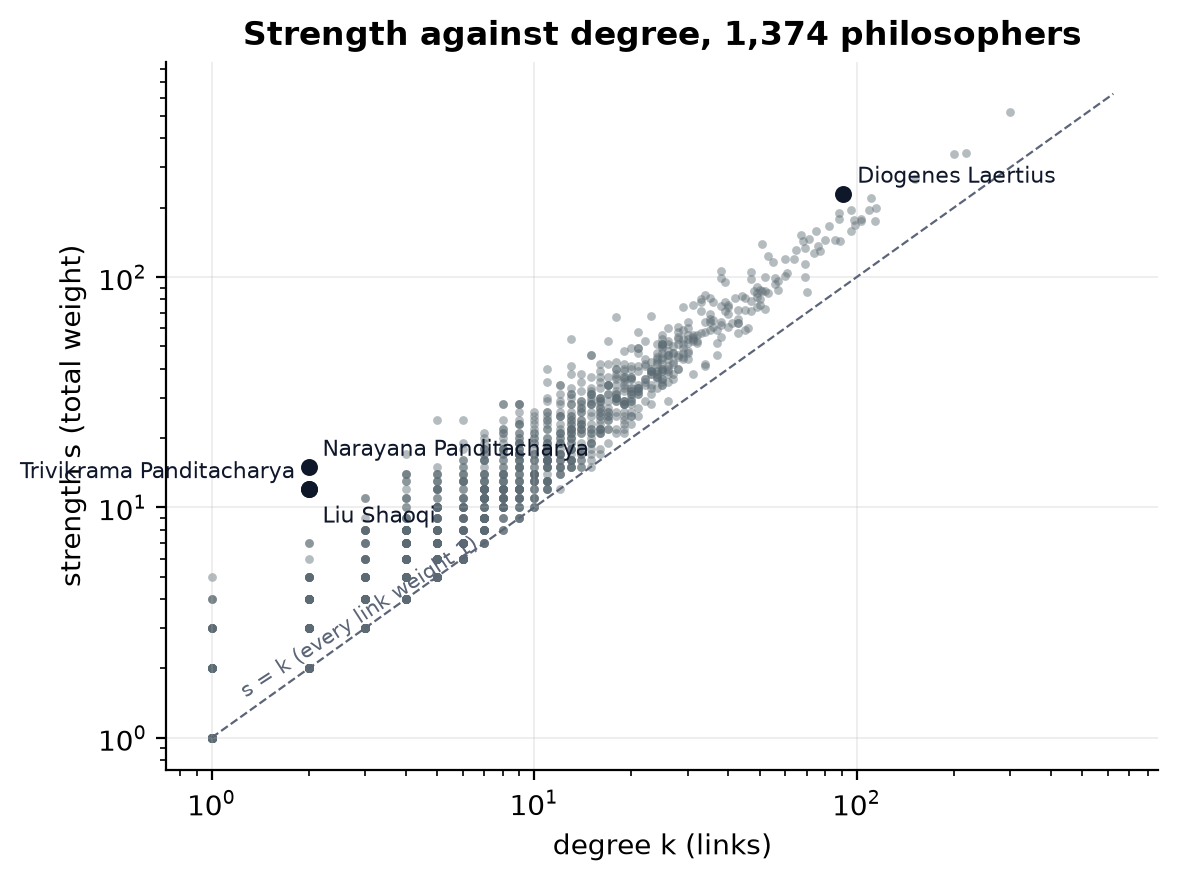

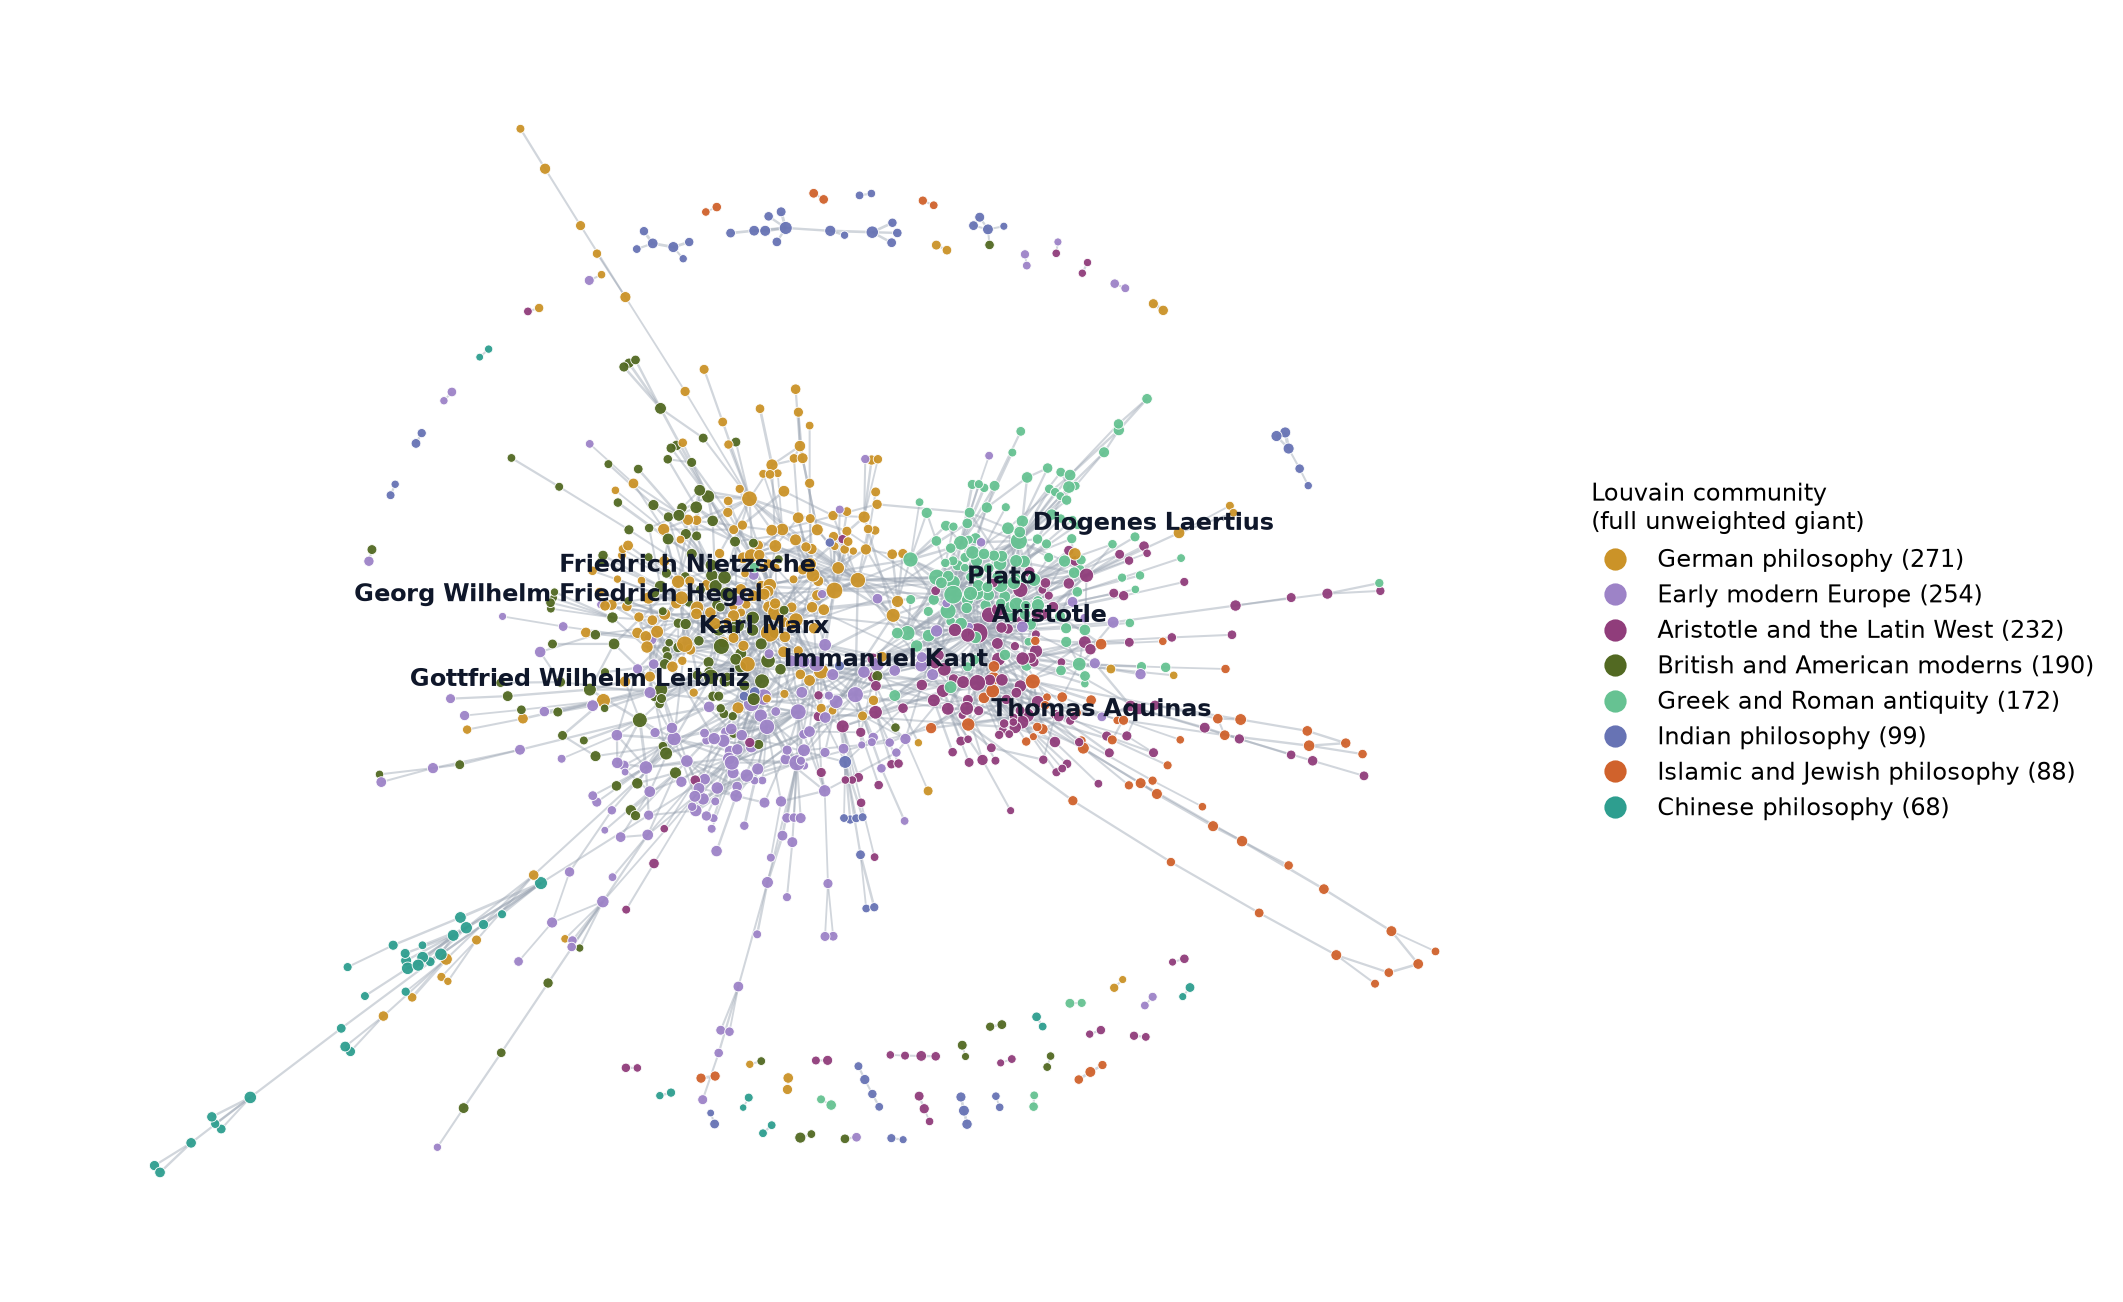

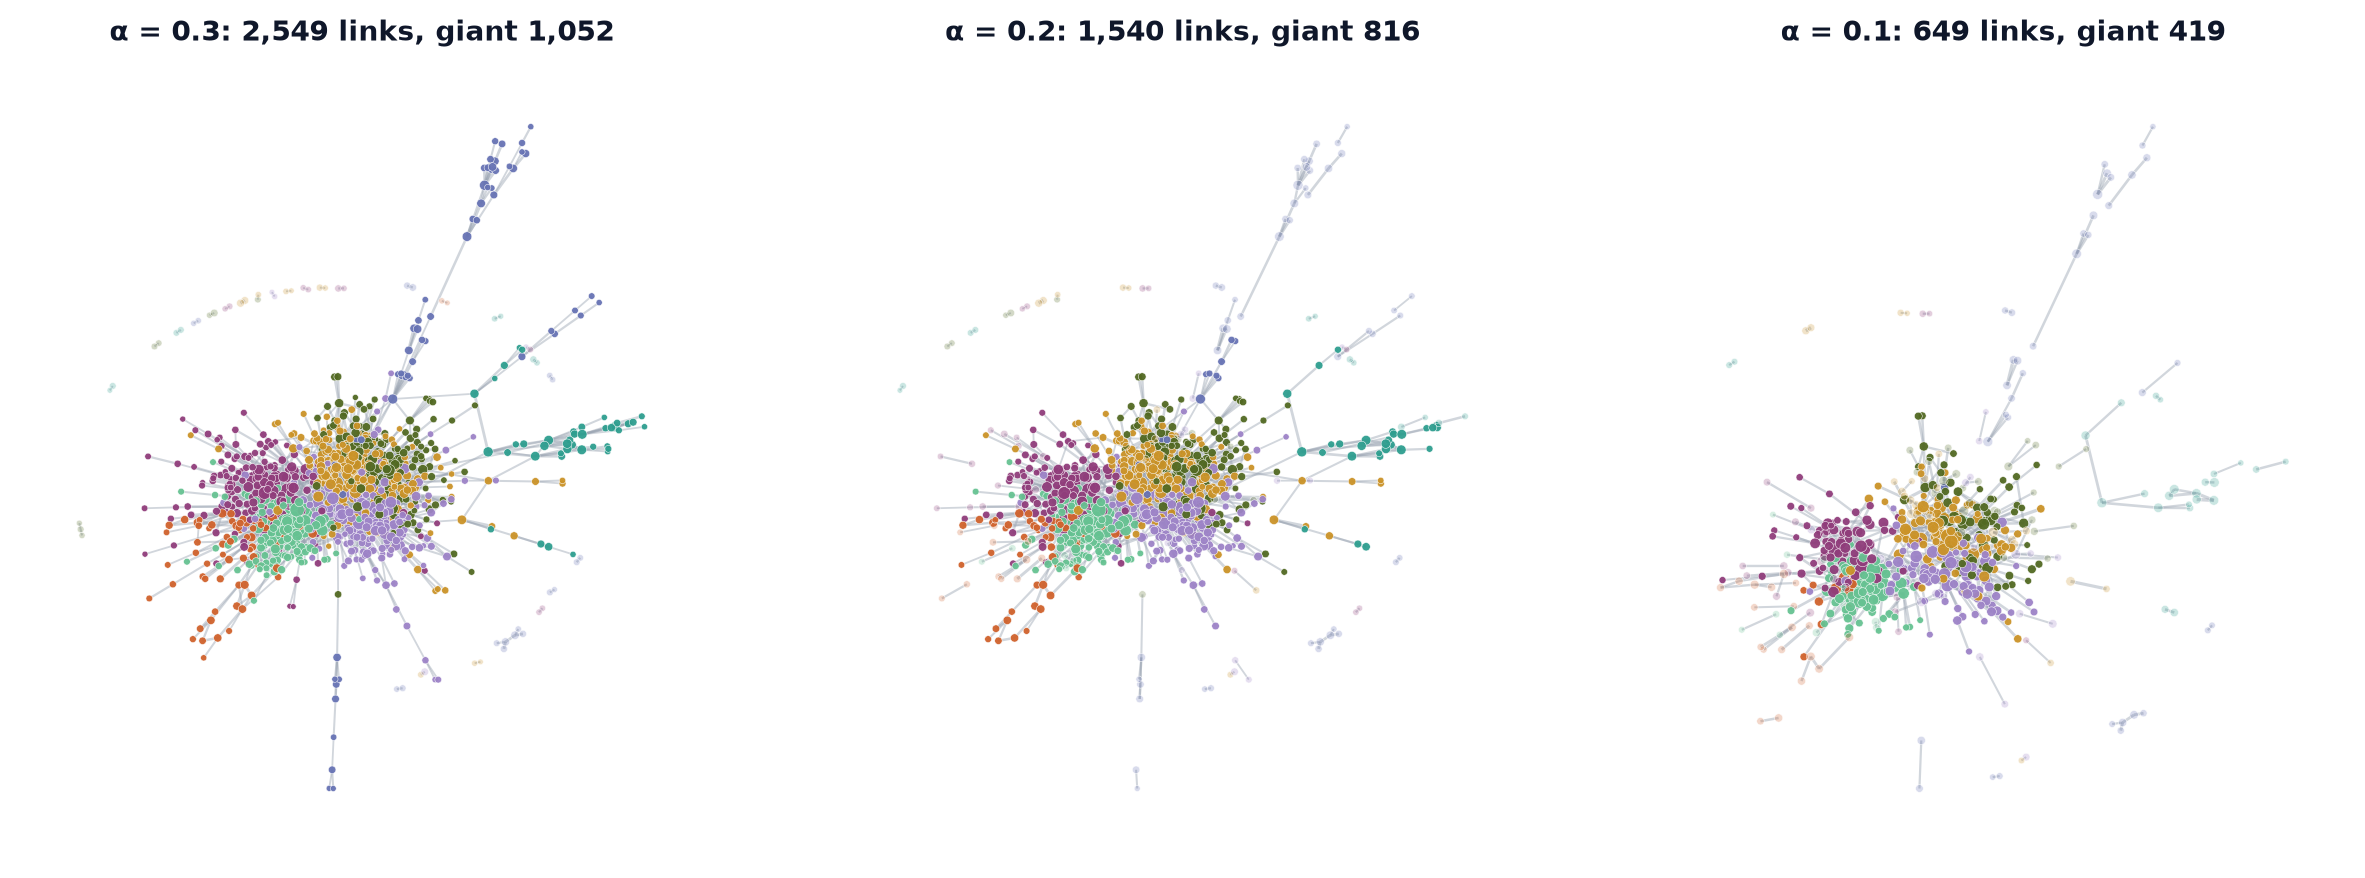

In [6]:
from IPython.display import Image, display
w4.figures()
for f in ('strength-vs-degree', 'backbone-alpha-0.2', 'backbone-three-alphas'):
    display(Image(f'../../figures/week4/{f}.png'))

## 6 · Validación leyendo Wikipedia

- **Gaudapada – The Buddha** (w = 2, primer quiebre ≥ 20, α = 0.297). El artículo de Gaudapada discute la influencia budista en su *Māṇḍūkya Kārikā* (dos kārikās citan al Buddha). Puente intelectual real, y disputado.
- **Confucius – Voltaire** (w = 3, α = 0.170, la gigante cae bajo 50 %). Voltaire admiraba la ética y el gobierno de Confucio; el artículo de Confucio lo lista entre sus lectores occidentales. Puente real de recepción, no de diálogo.
- **Max Müller – Yajnavalkya / Maitreyi** (w = 1, α = 0.403, primer pedazo ≥ 5). Müller tradujo las Upanishads: el puente es un traductor victoriano, no un filósofo del mismo mundo.